In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv


In [2]:
train = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv")
ss = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv")

/tmp/ipykernel_58/3205134266.py:1: DtypeWarning: Columns (38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv")


This project is made to predict the TargetValue which is the selling price of Heavy Equipments based on features like operational, technical and transactional specifications.
The evaluation metric is based on RMSLE score which stands for Root Mean Squared Logarithmic Error. The goal is to explore the dataset and build regression model for predicting the prices using ML techniques.


In [4]:
train.head()

,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,...,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


In [5]:
train.info()
train.isnull().sum().sort_values(ascending=False).head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  object 
 5   VendorPartnerID            138701 non-null  object 
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   object 
 9   TransactionDate            138701 non-null  object 
 10  Spec_FullDescriptor        138701 non-null  object 
 11  Spec_BaseClass             138701 non-null  object 
 12  Spec_SubClass              101716 non-null  object 
 13  Spec_ReleaseSeries         32

col19                 138635
col18                 138635
col5                  128320
col4                  128320
col27                 123742
col28                 123742
col29                 119829
col30                 119829
col13                 115296
col14                 115296
col7                  115296
col6                  115296
col9                  115296
col8                  115296
col11                 115296
col3                  109448
Forks                 109382
Spec_ReleaseSeries    105805
col1                  104915
col12                 100337
dtype: int64

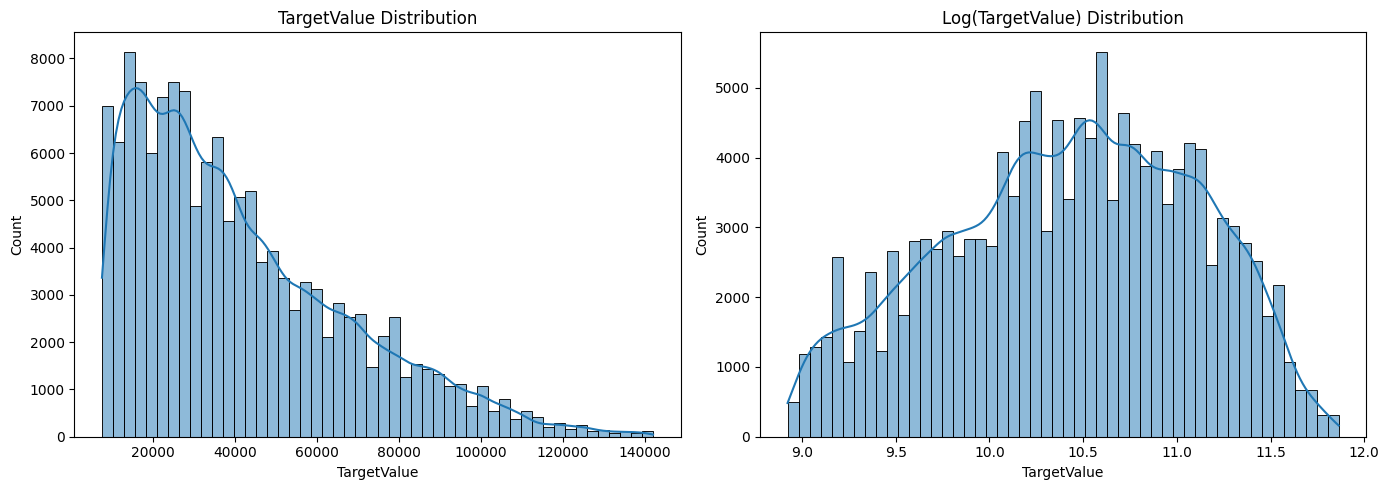

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(train["TargetValue"], bins= 50,ax=ax[0], kde=True)
ax[0].set_title("TargetValue Distribution")
sns.histplot(np.log1p(train["TargetValue"]), bins=50, ax=ax[1], kde=True)
ax[1].set_title("Log(TargetValue) Distribution")
plt.tight_layout()
plt.show()

TargetValue is right skewed which implies that most of the equipments sell in a lower price range. Also, in the second graph after the log transformation, the distribution is far more symmetric, which justifies the use of log transformed values for training the model.

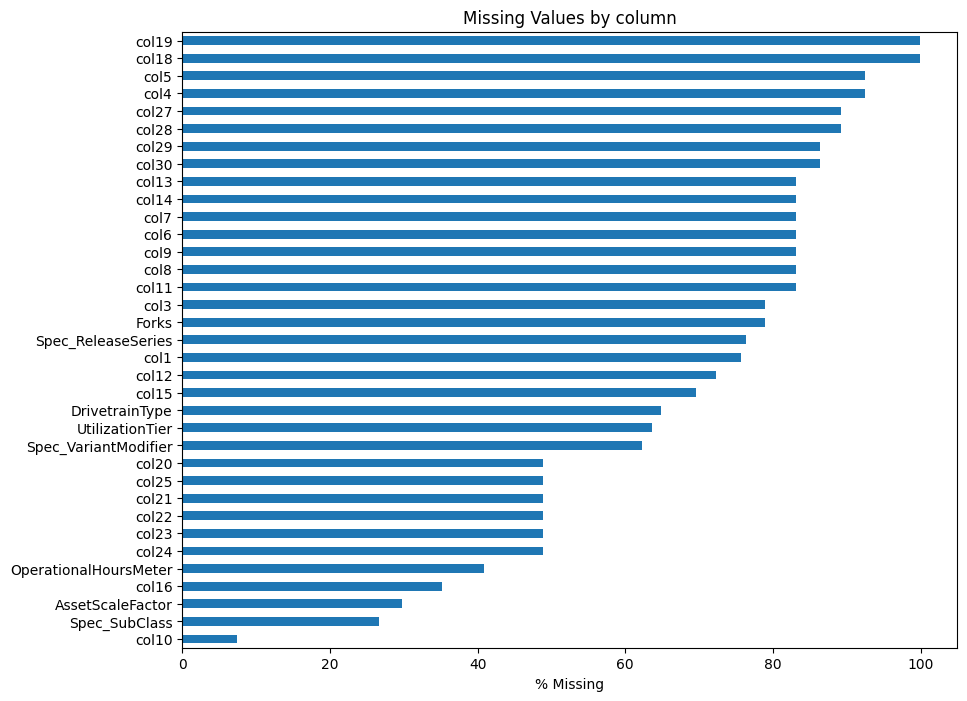

In [7]:
missing= train.isnull().mean().sort_values(ascending=False)*100
missing = missing[missing>0]

plt.figure(figsize=(10,8))
missing.plot(kind="barh")
plt.xlabel("% Missing")
plt.title("Missing Values by column")
plt.gca().invert_yaxis()
plt.show()

Some columns like 18 and 19 are missing in most of the rows which is likely because the column is of optional equipment specifications.

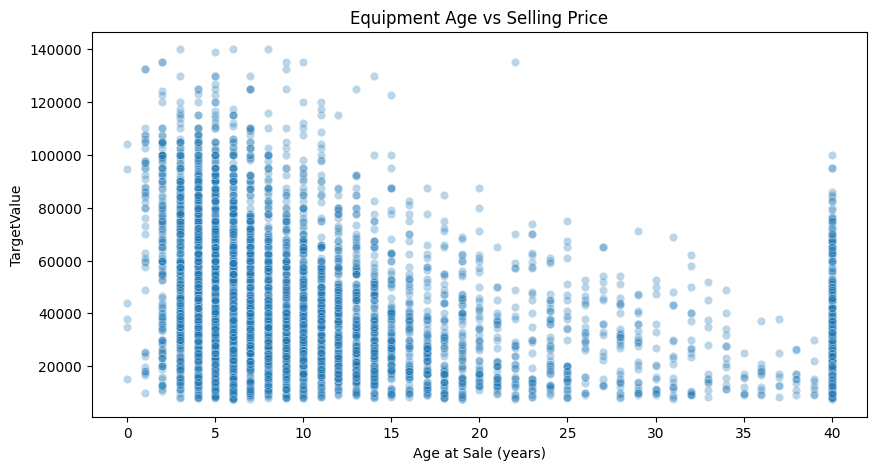

In [9]:
train["equipment_age_temp"] = pd.to_datetime(train["TransactionDate"]).dt.year - train["ManufactureYear"]
train["equipment_age_temp"] = train["equipment_age_temp"].clip(lower=0, upper=40)
plt.figure(figsize=(10,5))
sns.scatterplot(data=train.sample(5000, random_state=42), x="equipment_age_temp",y="TargetValue", alpha=0.3)
plt.title("Equipment Age vs Selling Price")
plt.xlabel("Age at Sale (years)")
plt.show()

A negative relationship between equipment age and price is observed. Newer equipments have higher prices whereas when the equipment age is increasing the price is depreciated. 
This is why Equipment age is a valuable engineered feature.

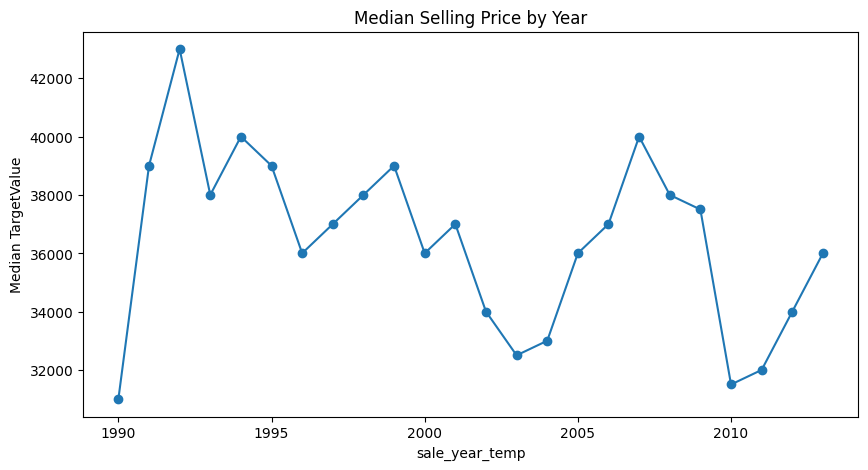

In [10]:
train["sale_year_temp"] = pd.to_datetime(train["TransactionDate"]).dt.year

yearly_avg = train.groupby("sale_year_temp") ["TargetValue"].median()
plt.figure(figsize=(10,5))
yearly_avg.plot(marker="o")
plt.title("Median Selling Price by Year")
plt.ylabel("Median TargetValue")
plt.show()

Median selling price varies across years,inflations, various market trends. This is why sale_year is included as a model feature and hence price is not considered fixed over time.

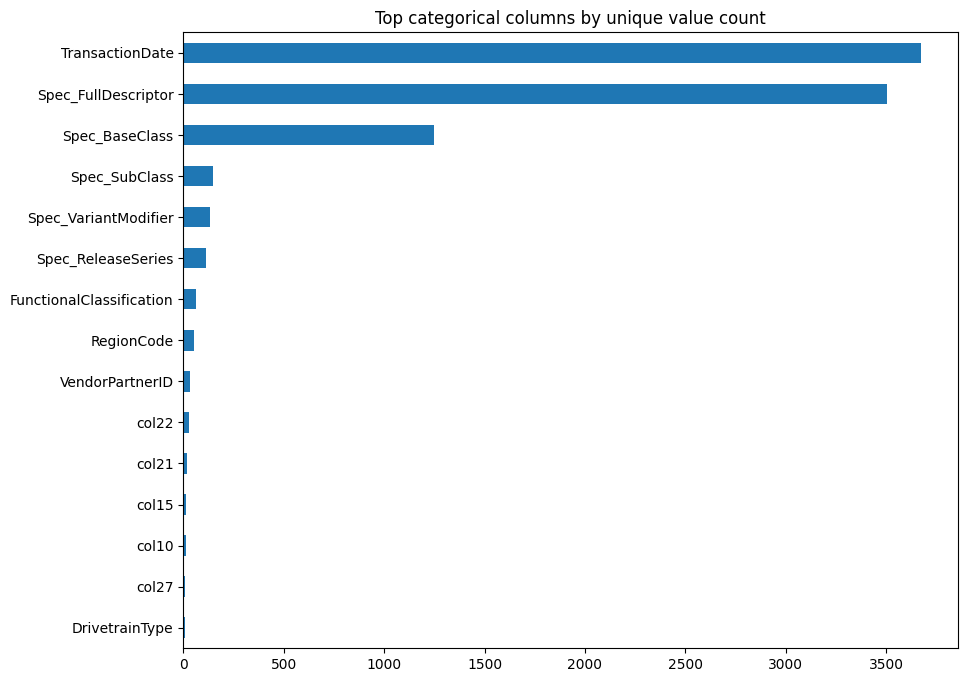

In [11]:
cat_cols_preview = train.select_dtypes(include="object").columns
cardinality = train[cat_cols_preview].nunique().sort_values(ascending=False)
plt.figure(figsize=(10,8))
cardinality.head(15).plot(kind="barh")
plt.title("Top categorical columns by unique value count")
plt.gca().invert_yaxis()
plt.show()

Transaction date appears to be on top with most unique values but it is because the TransactionDate is still being stored as raw text at this stage and there is a unique timestamp for each transaction hence it is not a proper categorical feature.
Among the actual categorical columns, Spec_FullDescriptor and Spec_BaseClass have more unique values when compared to the rest.
Label encoding is therefore used instead of one_hot to avoid creation of thousands of extra columns.

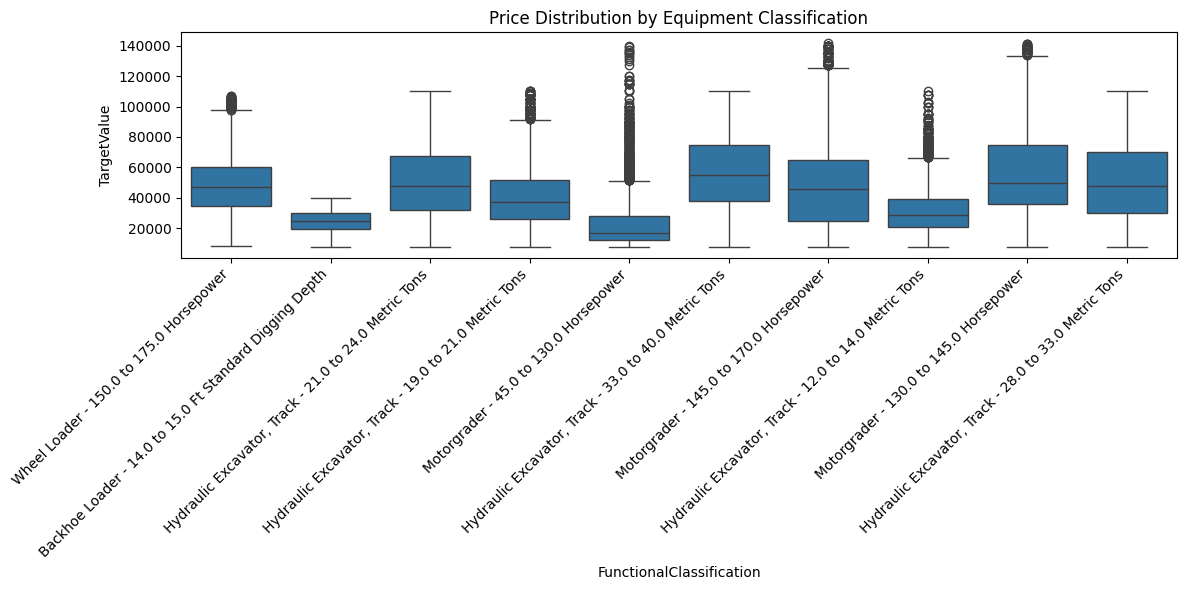

In [12]:
plt.figure(figsize=(12,6))
top_categories = train["FunctionalClassification"].value_counts().head(10).index
sns.boxplot(data=train[train["FunctionalClassification"].isin(top_categories)],
            x="FunctionalClassification", y="TargetValue")
plt.xticks(rotation= 45, ha="right")
plt.title("Price Distribution by Equipment Classification")
plt.tight_layout()
plt.show()

Price varies a lot across the functional classification categories and gives information of power, size and equipment type. 
Bigger and powerful machines sell for more price.
Some categories also show high price outliers. The 45 to 130 horsepower motorgrader has a lot of dots above the box which clearly shows that most of units sell for less price but a good number sell for much more.

In [13]:
train = train.drop(columns=["equipment_age_temp", "sale_year_temp", "_age_temp", "_year_temp"], errors="ignore")

In [14]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
def features(df):
    df=df.copy()
    df["TransactionDate"]=pd.to_datetime(df["TransactionDate"])
    df["sale_year"]=df["TransactionDate"].dt.year
    df["sale_month"]=df["TransactionDate"].dt.month
    df["equipment_age"]= (df["sale_year"]-df["ManufactureYear"]).clip(lower=0)
    return df

def preprocess(train_df,test_df,drop_cols):
    train_df = features(train_df)
    test_df = features(test_df)
    
    train_df= train_df.drop(columns= drop_cols)
    test_df= test_df.drop(columns= [c for c in drop_cols if c in test_df.columns])
    
    cat_cols= train_df.select_dtypes(include=["object"]).columns.tolist()
    if "TargetValue" in cat_cols: cat_cols.remove("TargetValue")
    num_cols= train_df.select_dtypes(include=[np.number]).columns.tolist()
    if "TargetValue" in num_cols: num_cols.remove("TargetValue")
    combined= pd.concat([train_df[cat_cols], test_df[cat_cols]], axis=0)
    for col in cat_cols:
        combined[col]= combined[col].fillna("missing").astype(str)
        le= LabelEncoder()
        combined[col]= le.fit_transform(combined[col])
        train_df[cat_cols]= combined.iloc[:len(train_df)][cat_cols].values
        test_df[cat_cols]= combined.iloc[len(train_df):][cat_cols].values

    for col in num_cols:
        median_val= train_df[col].median()
        train_df[col]=train_df[col].fillna(median_val)
        test_df[col]=test_df[col].fillna(median_val)

    scaler= StandardScaler()
    train_scaled_num= pd.DataFrame(scaler.fit_transform(train_df[num_cols]),columns= num_cols, index=train_df.index)
    test_scaled_num= pd.DataFrame(scaler.transform(test_df[num_cols]),columns= num_cols, index=test_df.index)
    return train_df, test_df, cat_cols, num_cols, train_scaled_num, test_scaled_num

drop_cols= ["TransactionID", "TransactionDate", "col18", "col19"]
train, test, cat_cols, num_cols, train_scaled_num, test_scaled_num= preprocess(train, test, drop_cols)

feature_cols=cat_cols+num_cols
X= train[feature_cols]
Y= np.log1p(train["TargetValue"])

* Missing values are handeled differently based on its type. The categorical missing values are encoded as "missing" whereas in case of numerical missing values, they are filled with training set's median to avoid leakage from test set.
  
* The preprocessing steps have reusable functions which have been applied identically to training and testing datadsetes to ensure consistency.
  

In [15]:
import re
train_raw= pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv")
test_raw= pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv")

def extract_range_avg(text):
    if pd.isna(text): return np.nan
    nums = [float(n) for n in re.findall(r"[\d.]+", str(text))]
    return np.mean(nums) if nums else np.nan

train["spec_range_avg"] = train_raw["FunctionalClassification"].apply(extract_range_avg)
test["spec_range_avg"] = test_raw["FunctionalClassification"].apply(extract_range_avg)

train["spec_range_avg"] = train["spec_range_avg"].fillna(train["spec_range_avg"].median())
test["spec_range_avg"] = test["spec_range_avg"].fillna(train["spec_range_avg"].median())  

drop_low_importance= ["AssetID", "InventoryGroupDescription", "col30", "col5","col19" ]
feature_cols_final= [c for c in feature_cols if c not in drop_low_importance]+["spec_range_avg"]
X_final= train[feature_cols_final]

/tmp/ipykernel_58/484583906.py:2: DtypeWarning: Columns (38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  train_raw= pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv")


Two features were added based on the observations from EDA-
* **equipment_age**=sale_year-manufacture_year
  This was done because EDA showed a negative relation between price and age.
* **spec_range_avg** gives the horsepower/tonnage by extracting information from the text tables of Functional classification, giving a direct access to the numeric values of equipment size.

Access ID was excluded as it behaved more like a unique identifier rather than a predictive feature. Several other columns like col30,col5 with almost zero importance were also removed to reduce noise.

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_final, Y, test_size=0.2, random_state=42)

The data is split into training and validation sets in the ratio 80/20 for checking the performance of model on data which is out of the sample, before submitting the model to competition.

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

lr_model= LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds= lr_model.predict(X_val)
lr_rmsle= np.sqrt(mean_squared_error(y_val, lr_preds))
print("Linear Regression Validation RMSLE:", lr_rmsle)

Linear Regression Validation RMSLE: 0.5182253471309708


Linear Regression tends to assume that price varies linearly with each feature but from the EDA it is clearly visible that its not the case and that the age has a curved relationship with the price.
Also in case of categorical values, numeric values are assigned as labels that denote something that does not have an actual numeric meaning. Linear Regression wrongly assumes it as a numeric value due to which the scores are worse than the tree based models.

In [18]:
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
lgbm_model= LGBMRegressor(n_estimators=2500, learning_rate= 0.025, num_leaves= 180, max_depth=16, min_child_samples=8, random_state=42)
lgbm_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=[early_stopping(80), log_evaluation(0)])
lgbm_preds= lgbm_model.predict(X_val)
lgbm_rmsle= np.sqrt(mean_squared_error(y_val,lgbm_preds))
print("LightGBM Validation RMSLE:", lgbm_rmsle)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017614 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1886
[LightGBM] [Info] Number of data points in the train set: 110960, number of used features: 45
[LightGBM] [Info] Start training from score 10.424734
Training until validation scores don't improve for 80 rounds
Did not meet early stopping. Best iteration is:
[2499]	valid_0's l2: 0.0411933
LightGBM Validation RMSLE: 0.20296124099692608


LightGBM was chosen because it uses trees, in which each tree tries to correct the errors of the previous trees. This kind of arrangement is useful for dealing with numerical/categorical data and missing values.
Hyperparametes on the other hand were tuned manually in various iterations to avoid the risk of overfitting and increasing accuracy.

In [19]:
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMRegressor
param_dist_lgbm={
    'num_leaves':[100,150,180,220],
    'max_depth' :[10,12,14,16],
    'learning_rate': [0.02, 0.025, 0.03, 0.04],
    'min_child_samples':[5, 8,10,15]
}
random_search_lgbm= RandomizedSearchCV(
    estimator= LGBMRegressor(n_estimators=1200, random_state=42),
    param_distributions=param_dist_lgbm,
    n_iter=12,
    scoring='neg_mean_squared_error',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
random_search_lgbm.fit(X_train, y_train)
print("Best LightGBM parameters",random_search_lgbm.best_params_)

best_lgbm= random_search_lgbm.best_estimator_
lgbm_tuned_preds= best_lgbm.predict(X_val)
lgbm_tuned_rmsle= np.sqrt(mean_squared_error(y_val,lgbm_tuned_preds))
print("Tuned LightGBM Validation RMSLE:", lgbm_tuned_rmsle)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028786 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1856
[LightGBM] [Info] Number of data points in the train set: 73973, number of used features: 45
[LightGBM] [Info] Start training from score 10.424863
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightG

Another method of hyperparmeter tuning was used other than the manual way. RandomizedSearchCV was used for more systematic way to search the hyperparameters at which the scores are the best
RandomizedSearchCV was used over GridSearchCV mainly because it would take a much longer time as GridSearchCV would test every single combination which would be very time consuming.
Best combination it found was num_leaves=180, max_depth=12, learning_rate=0.04, min_child_samples=15, giving a validation RMSLE of 0.2040.
This score is very close to the earlier score where the hyperparameter tuning was done manually which implies that the tuning done manually was in a good range.


In [20]:
importance= pd.Series(lgbm_model.feature_importances_, index=feature_cols_final).sort_values(ascending=False)
print(importance.head(15))

RegionCode                  44445
Spec_FullDescriptor         36082
equipment_age               35030
ProductConfigID             34562
sale_month                  33340
sale_year                   32521
ManufactureYear             31908
OperationalHoursMeter       27548
VendorPartnerID             19202
Spec_SubClass               18209
FunctionalClassification    17793
spec_range_avg              16661
Spec_BaseClass               9525
CabinType                    9489
Spec_VariantModifier         8579
dtype: int32


In [21]:
from xgboost import XGBRegressor

xgb_model= XGBRegressor(n_estimators=2000, learning_rate=0.03, max_depth=8, subsample=0.8, colsample_bytree=0.8, random_state=42)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
xgb_preds= xgb_model.predict(X_val)
xgb_rmsle= np.sqrt(mean_squared_error(y_val, xgb_preds))
print("XGBoost Validation RMSLE:", xgb_rmsle)

XGBoost Validation RMSLE: 0.20150973874864922


XGBoost is also a boosting model which was used for comparison and testing if the LightGBM model was actually working with the dataset or gave good validation scores due to the the particular split or due to something specific in feature engineering.
In LightGBM model the tree grows from the leaf that gives the least error resulting in uneven trees formation.
XGBoost on the other hand, grows trees level-wise, splitting each leaf which results in balanced trees.
Since both the models have relatively close scores it shows that the features and preprocessing is actually working and not just a coincidence.

In [23]:
from xgboost import XGBRegressor
param_dist_xgb={
    'max_depth':[6,8,10],
    'learning_rate': [0.02, 0.03, 0.04],
    'subsample':[0.7, 0.8, 0.9],
    'colsample_bytree':[0.7, 0.8, 0.9]
}
random_search_xgb= RandomizedSearchCV(
    estimator= XGBRegressor(n_estimators=1200, random_state=42),
    param_distributions=param_dist_xgb,
    n_iter=12,
    scoring='neg_mean_squared_error',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
random_search_xgb.fit(X_train, y_train)
print("Best XGBoost parameters",random_search_xgb.best_params_)

best_xgb= random_search_xgb.best_estimator_
xgb_tuned_preds= best_xgb.predict(X_val)
xgb_tuned_rmsle= np.sqrt(mean_squared_error(y_val,xgb_tuned_preds))
print("Tuned XGBoost Validation RMSLE:", xgb_tuned_rmsle)


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best XGBoost parameters {'subsample': 0.8, 'max_depth': 10, 'learning_rate': 0.03, 'colsample_bytree': 0.9}
Tuned XGBoost Validation RMSLE: 0.20044335659235035


Used the same RandomizedSearchCV for XGBoost as well after trying to tune the hyperparameters manually.
Best combination found was max_depth=10, learning_rate=0.03, subsample=0.8, colsample_bytree=0.9, giving a validation RMSLE of 0.2004. This score is a bit better than the manual score.

In [26]:
comparison=pd.DataFrame({
    "Model": ["Linear Regression", "LightGBM","Tuned LightGBM" ,"XGBoost","Tuned XGBoost"],
    "Validation RMSLE": [lr_rmsle, lgbm_rmsle, lgbm_tuned_rmsle,xgb_rmsle, xgb_tuned_rmsle],
    
})
comparison

,Model,Validation RMSLE
0,Linear Regression,0.518225
1,LightGBM,0.202961
2,Tuned LightGBM,0.203983
3,XGBoost,0.201510
4,Tuned XGBoost,0.200443


In [27]:
final_lgbm= LGBMRegressor(n_estimators=2500, learning_rate=0.025, num_leaves=180, max_depth=16, min_child_samples=8, random_state=42)
final_lgbm.fit(X_final,Y)

final_xgb = XGBRegressor(n_estimators=2000, learning_rate=0.03, max_depth=10, subsample=0.8, colsample_bytree=0.9, random_state=42)
final_xgb.fit(X_final,Y)

test_final= test[feature_cols_final]
final_preds_log= (final_lgbm.predict(test_final)*0.5)+(final_xgb.predict(test_final)*0.5)
final_preds= np.expm1(final_preds_log)

ss["TargetValue"]= final_preds
ss.to_csv("submission.csv", index=False)
ss["TargetValue"].describe()

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018933 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1904
[LightGBM] [Info] Number of data points in the train set: 138701, number of used features: 45
[LightGBM] [Info] Start training from score 10.424111


count     15000.000000
mean      40858.135208
std       24850.056285
min        7667.872159
25%       20929.359784
50%       34597.797650
75%       56309.990496
max      140446.967903
Name: TargetValue, dtype: float64

For the final submission, the average of both the models is considered to produce a more stable prediction. Both models make different errors in different rows and hence averaging them cancels the individual mistakes. The 100% of training data is used to train the final model on a larger dataset so the model can learn more patterns from real data that is available.